In [15]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [16]:
from hexgrid import HexCoord, HexGrid, build_obstacle_map, get_neighbors_at_radius, VelocityState
from hexstar import HStarProblem, HStarSearch, h_cost_travel_time, construct_full_solution
from hexplot import plot_hex_grid_2, plot_velocity_profile

import matplotlib.pyplot as plt
import itertools



In [17]:
RADIUS = 45
MAP_JPG_SIZE = 1000 # largest dimension in px
a_max = 2
a_min = 8
ay_window_ms = 10

collision_radius = 1

jps_horizon = None
n_step = 5

In [18]:
obs_density = 0.07
hex_size = 1
n_obs = int(obs_density * 3 * RADIUS * (RADIUS + 1))
start = HexCoord(q=-RADIUS + 4, r=RADIUS - 4)
#start = HexCoord(0,0)
goal = HexCoord(q=RADIUS - 4, r=-RADIUS + 4)

obs = build_obstacle_map(
    center = HexCoord(0,0),
    radius = RADIUS,
    types = [("random_n", {"n": n_obs})],
    exclude=[start, goal],
    seed=42
)
from hexgrid import hexes_in_between_solid
from_hex = HexCoord(q = -RADIUS//2 + 5, r = -RADIUS // 2 + 5)
to_hex = HexCoord(q = RADIUS // 2 - 5, r = RADIUS // 2 - 5)
line = hexes_in_between_solid(from_hex, to_hex) 
obs = set(obs.keys()).union(line)


for i in range(5):
    obs = obs - get_neighbors_at_radius(start, i)
    obs = obs - get_neighbors_at_radius(goal, i)


obs = obs.union(get_neighbors_at_radius(HexCoord(0,0), RADIUS))

In [21]:


hg = HexGrid(hex_size, obs)

problem = HStarProblem(
    hg, # hex grid
    start,
    goal,
    a_max,  # maximum acceleration (for acceleration phase)
    a_min,  # maximum deceleration (positive value; used with sign as needed)
    collision_radius = collision_radius,
    jps_horizon =  jps_horizon,
    ay_window_ms = ay_window_ms,
    n_step = n_step,   
    start_v = VelocityState(0, None),
    goal_v = VelocityState(0, None)
)
#problem.goal_v=VelocityState(0, problem.DIRECTIONS.index(HexCoord(-1,2))) # approach from the northeast
hs = HStarSearch(
    problem = problem,
    heuristic = h_cost_travel_time
)


<Axes: title={'center': 'Hex grid (radius=45) centered at (0,0) Map'}, xlabel='x', ylabel='y'>

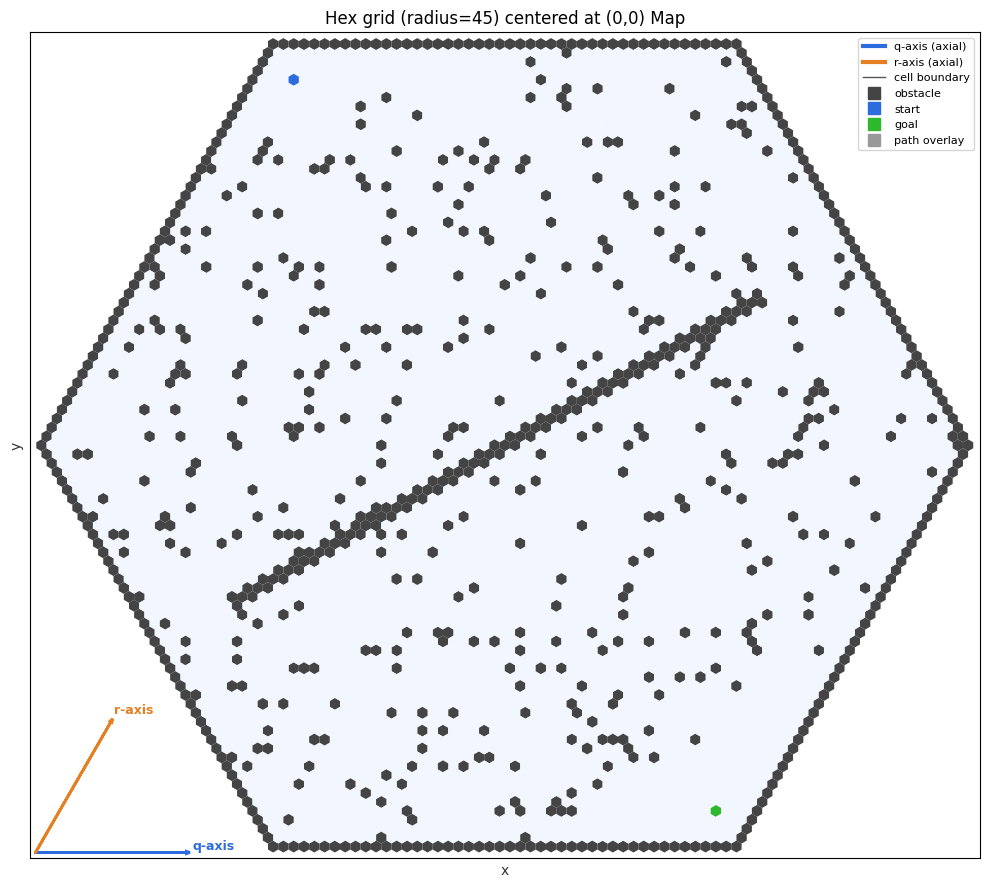

In [22]:
plot_hex_grid_2(
    hg.obstacles,#.union(problem.collision_radius_map),
    start,
    HexCoord(0,0),
    RADIUS,
    goal = goal,
    figsize=(10,10),
    show_coords = False,
    #path = hexes_in_between_solid(HexCoord(q=0, r=0), HexCoord(q=14, r=10)),
    #path=problem.get_available_hexes_in_dir(start, problem.DIRECTIONS[0], ray_range = 50),
    #path=problem.actions(hs.root),
    #path=set(unique_direction_vectors_up_to_n(HexCoord(0,0), RADIUS)),
    facecolor_path = "#999999",
    #path = set([n.location for n in fsolution[-24:-21]]),
    #path = fsolution,
    linewidth=0,
    plt_title = f"Map",
    save_path=f"map-2",
)

In [7]:
import time
start_t = time.time()
fsolution = hs.search()
fsolution_path = construct_full_solution(fsolution)
search_time = time.time() - start_t
benchmarks = hs.get_benchmarks()
print(f'Search time: {benchmarks["search_time"]}s')
print(f'Solution cost: {benchmarks["solution_cost"]}')

Search time: 3.176906108856201s
Solution cost: 15.425749680837647


<Axes: title={'center': 'Hex grid (radius=45) centered at (0,0) Solution Forward'}, xlabel='x', ylabel='y'>

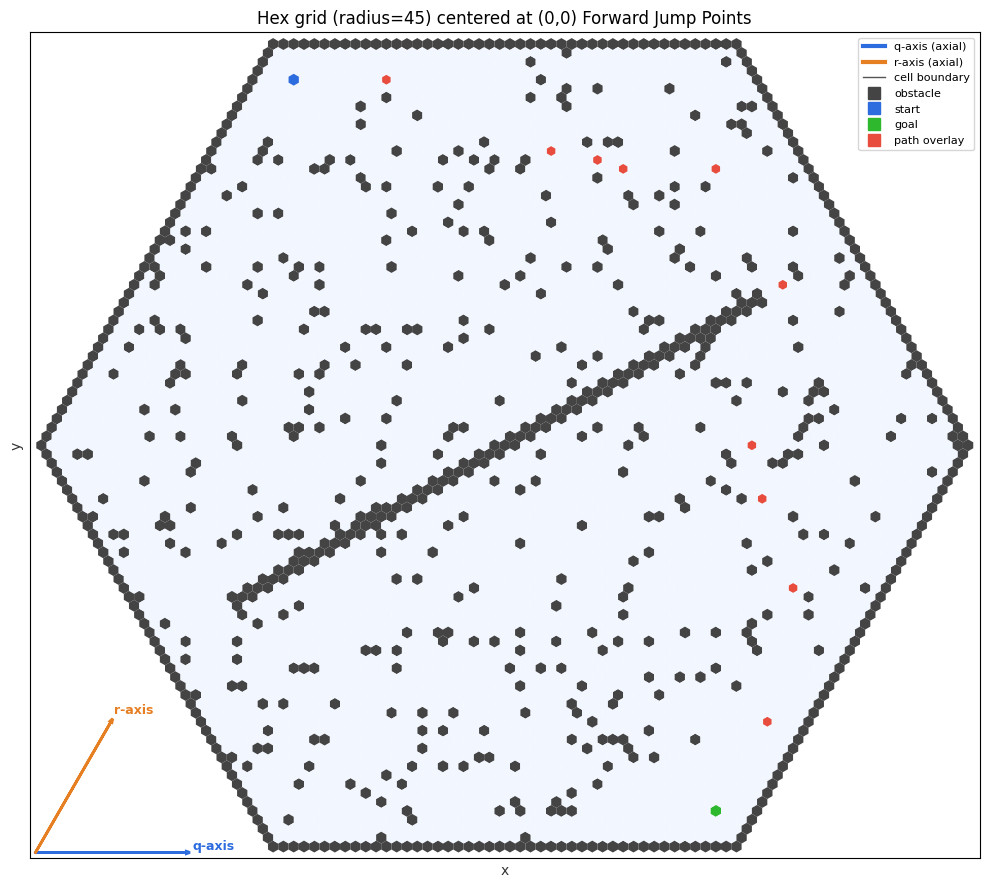

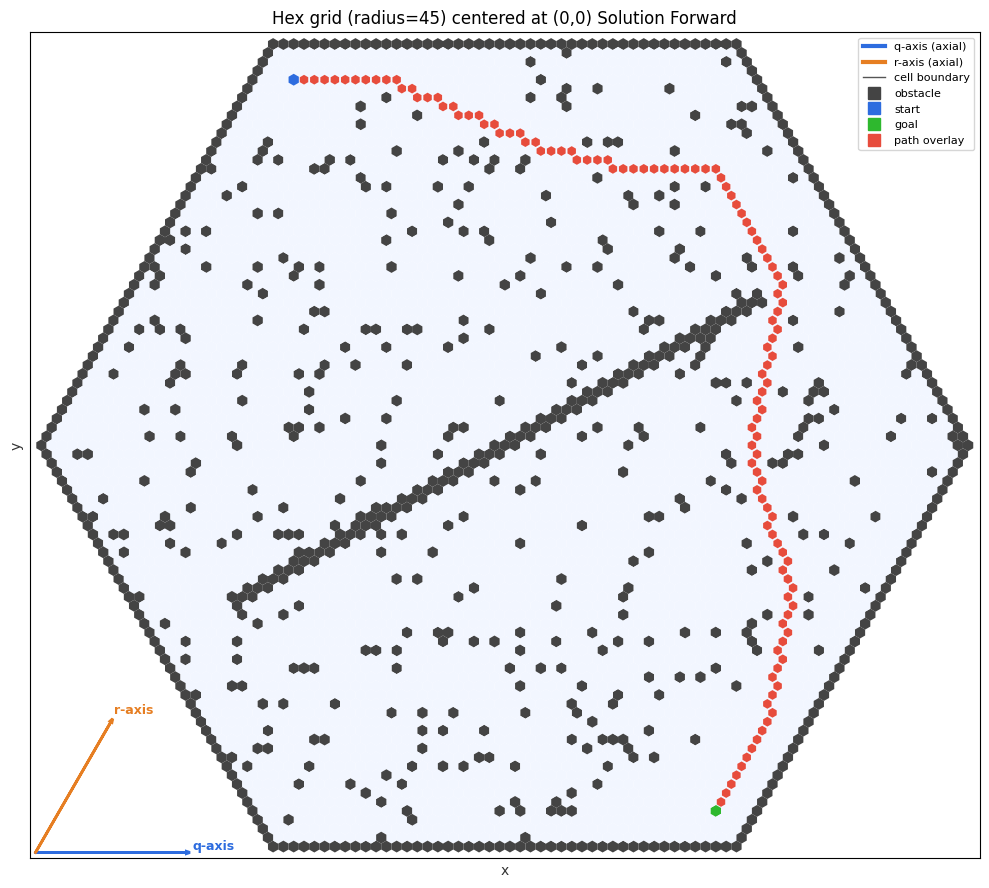

In [8]:
plot_hex_grid_2(
    obs,
    start,
    HexCoord(0,0),
    RADIUS,
    goal = goal,
    figsize=(10,10),
    show_coords = False,
    path = set([n.location for n in fsolution]),
    linewidth=0,
    plt_title = f"Forward Jump Points",
    save_path=f"jump-points-forward-2",
)
plot_hex_grid_2(
    obs,
    start,
    HexCoord(0,0),
    RADIUS,
    goal = goal,
    figsize=(10,10),
    show_coords = False,
    path = fsolution_path,
    linewidth=0,
    plt_title = f"Solution Forward",
    save_path=f"solution-forward-2",
)

In [9]:
# from hexgeometry import reverse_dir

# mag = fsolution[-1].velocity.magnitude
# d = problem.DIRECTIONS[fsolution[-1].velocity.direction]
# d = reverse_dir(d)
# d = problem.DIRECTIONS.index(d)
# d

# problem_r = problem.reverse(goal_speed_mag = mag, goal_heading_idx = d)
problem_r = problem.reverse()
problem_r.start_v

VelocityState(magnitude=0, direction=None)

In [10]:
hs_r = HStarSearch(
    problem = problem_r,
    heuristic = h_cost_travel_time
)

In [11]:
import time
start_t = time.time()
rsolution = hs_r.search()
rsolution_path = construct_full_solution(rsolution)
search_time = time.time() - start_t
benchmarks_r = hs_r.get_benchmarks()
print(f'Search time: {benchmarks_r["search_time"]}s')
print(f'Solution cost r: {benchmarks_r["solution_cost"]}')
print(f'Solution cost f: {benchmarks["solution_cost"]}')

Search time: 3.124182939529419s
Solution cost r: 15.759035325880248
Solution cost f: 15.425749680837647


In [14]:
[f.velocity.magnitude for f in fsolution]

[0,
 7.896444077714954,
 13.53333587984912,
 14.659474607556257,
 15.271885887126384,
 17.192566056929653,
 19.637998106107233,
 22.02213037195281,
 22.83932642787289,
 24.18951969644051,
 16.647165801151267,
 0]

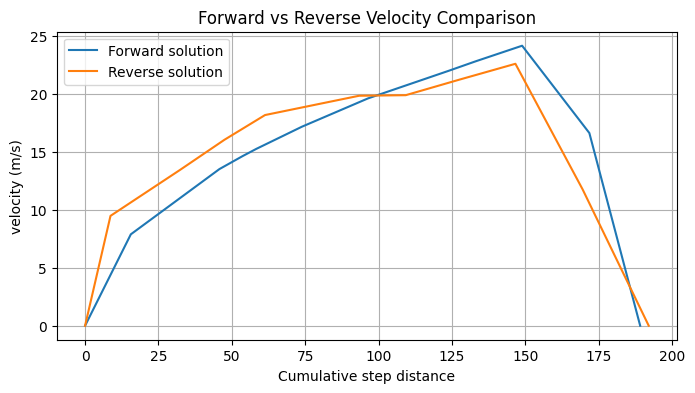

In [12]:
import itertools
f_x = list(itertools.accumulate(
    (f.step_distance or 0.0) for f in fsolution
))
r_x = list(itertools.accumulate(
    (f.step_distance or 0.0) for f in rsolution
))

f_vals = [f.velocity.magnitude for f in fsolution]
r_vals = list(reversed([f.velocity.magnitude for f in rsolution]))

plt.figure(figsize=(8, 4))

plt.plot(f_x, f_vals, label="Forward solution")
plt.plot(r_x, r_vals, label="Reverse solution")

plt.xlabel("Cumulative step distance")
plt.ylabel("velocity (m/s)")
plt.title("Forward vs Reverse Velocity Comparison")

plt.legend()
plt.grid(True)

plt.show()



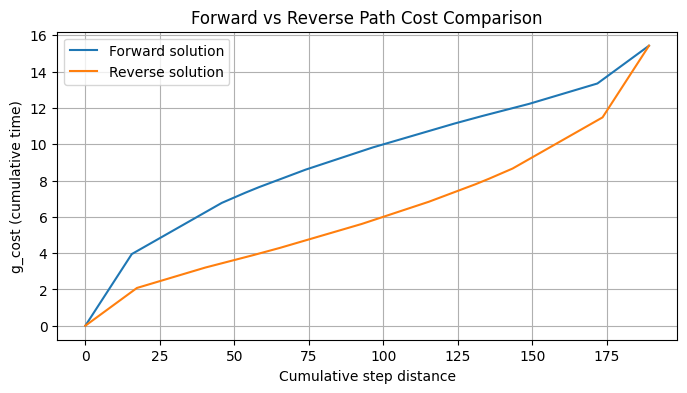

In [28]:
f_x = list(itertools.accumulate(
    (f.step_distance or 0.0) for f in fsolution
))
r_x = list(itertools.accumulate(
    (f.step_distance or 0.0) for f in rsolution
))

f_vals = [f.g_cost for f in fsolution]
r_vals = [f.g_cost for f in rsolution]

plt.figure(figsize=(8, 4))

plt.plot(f_x, f_vals, label="Forward solution")
plt.plot(r_x, r_vals, label="Reverse solution")

plt.xlabel("Cumulative step distance")
plt.ylabel("g_cost (cumulative time)")
plt.title("Forward vs Reverse Path Cost Comparison")

plt.legend()
plt.grid(True)

plt.show()

<Axes: title={'center': 'Hex grid (radius=45) centered at (0,0) Solution Reverse'}, xlabel='x', ylabel='y'>

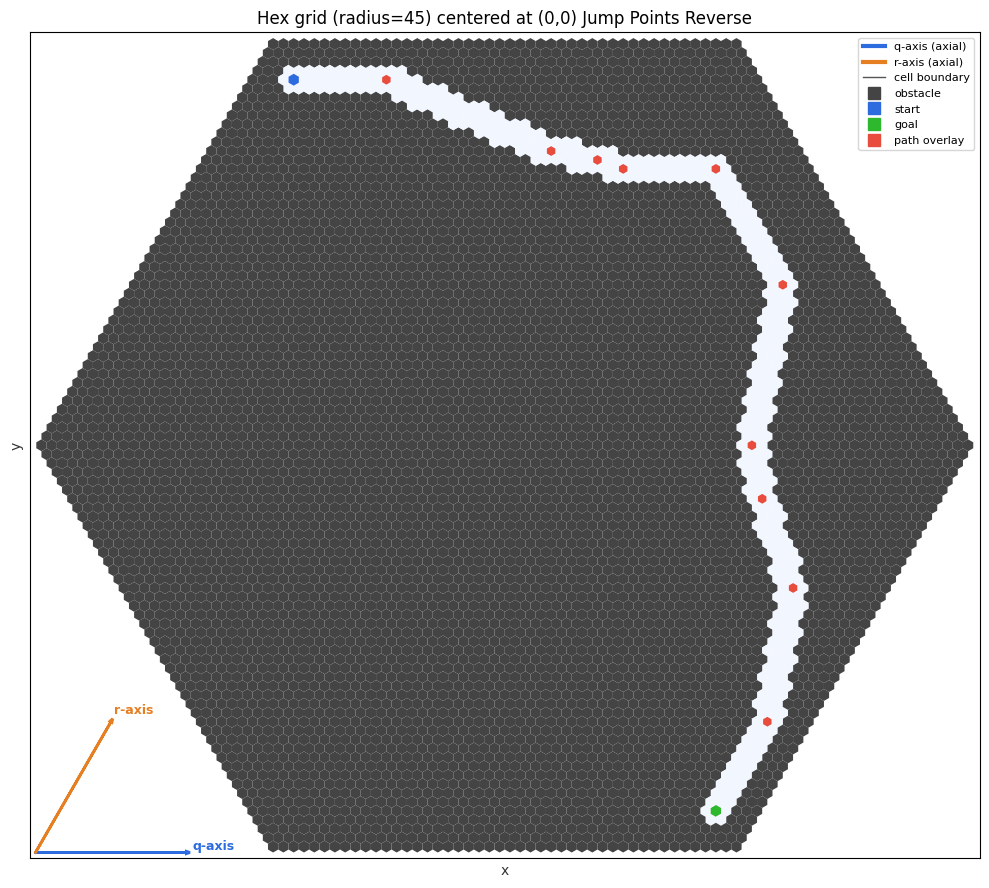

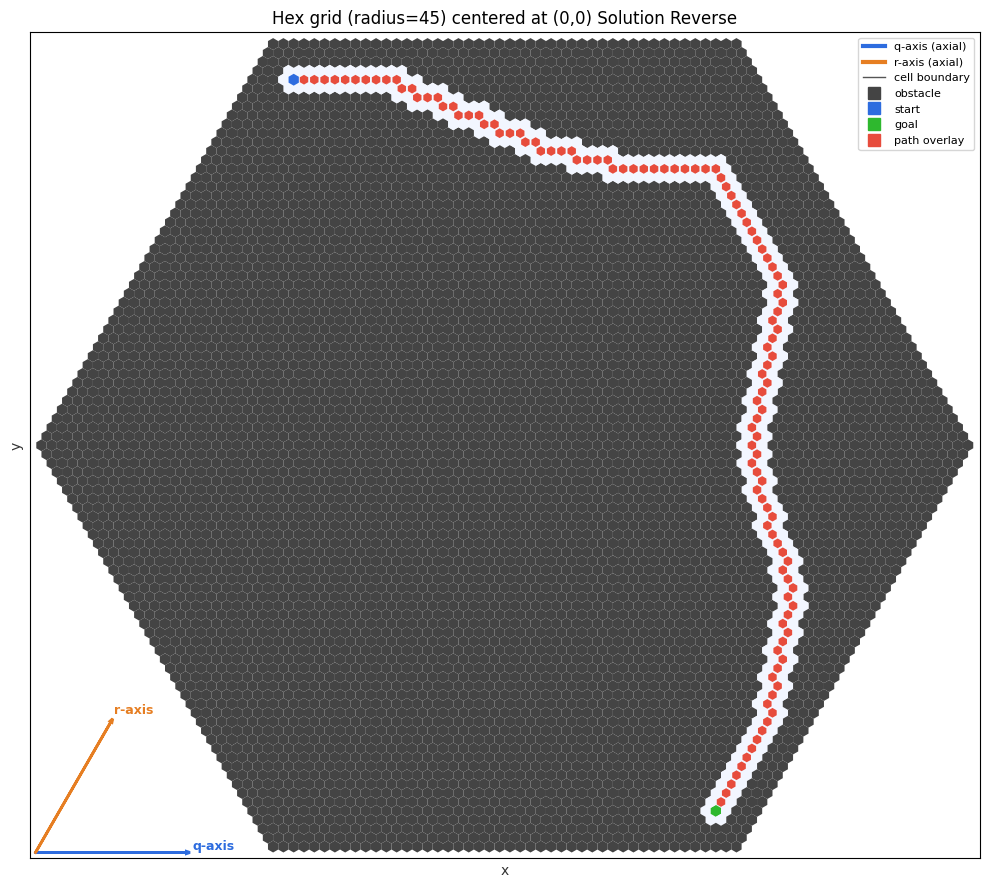

In [29]:
plot_hex_grid_2(
    obs,
    start,
    HexCoord(0,0),
    RADIUS,
    goal = goal,
    figsize=(10,10),
    show_coords = False,
    path = set([n.location for n in rsolution]),
    linewidth=0,
    plt_title = f"Jump Points Reverse",
    save_path=f"jump-points-reverse-2",
)
plot_hex_grid_2(
    obs,
    start,
    HexCoord(0,0),
    RADIUS,
    goal = goal,
    figsize=(10,10),
    show_coords = False,
    path = rsolution_path,
    linewidth=0,
    plt_title = f"Solution Reverse",
    save_path=f"solution-reverse-2",
)

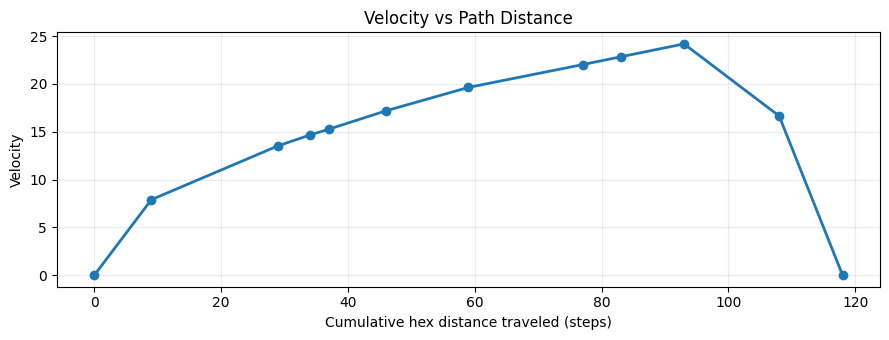

<Axes: title={'center': 'Velocity vs Path Distance'}, xlabel='Cumulative hex distance traveled (steps)', ylabel='Velocity'>

In [30]:
plot_velocity_profile(fsolution)

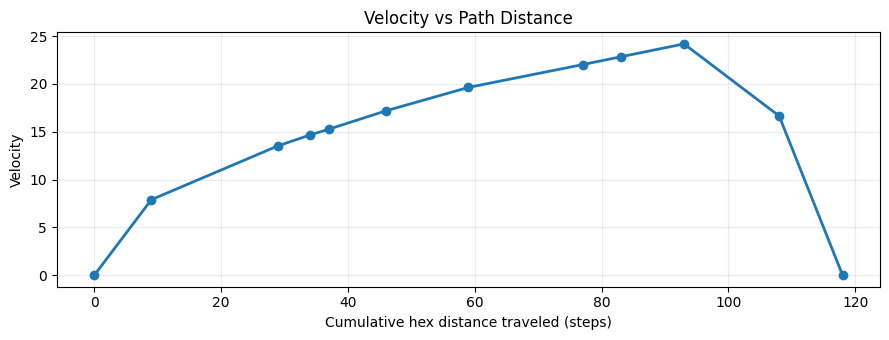

<Axes: title={'center': 'Velocity vs Path Distance'}, xlabel='Cumulative hex distance traveled (steps)', ylabel='Velocity'>

In [31]:
plot_velocity_profile(list(reversed(rsolution)))

<Axes: title={'center': 'Hex grid (radius=45) centered at (0,0) Map-constrained'}, xlabel='x', ylabel='y'>

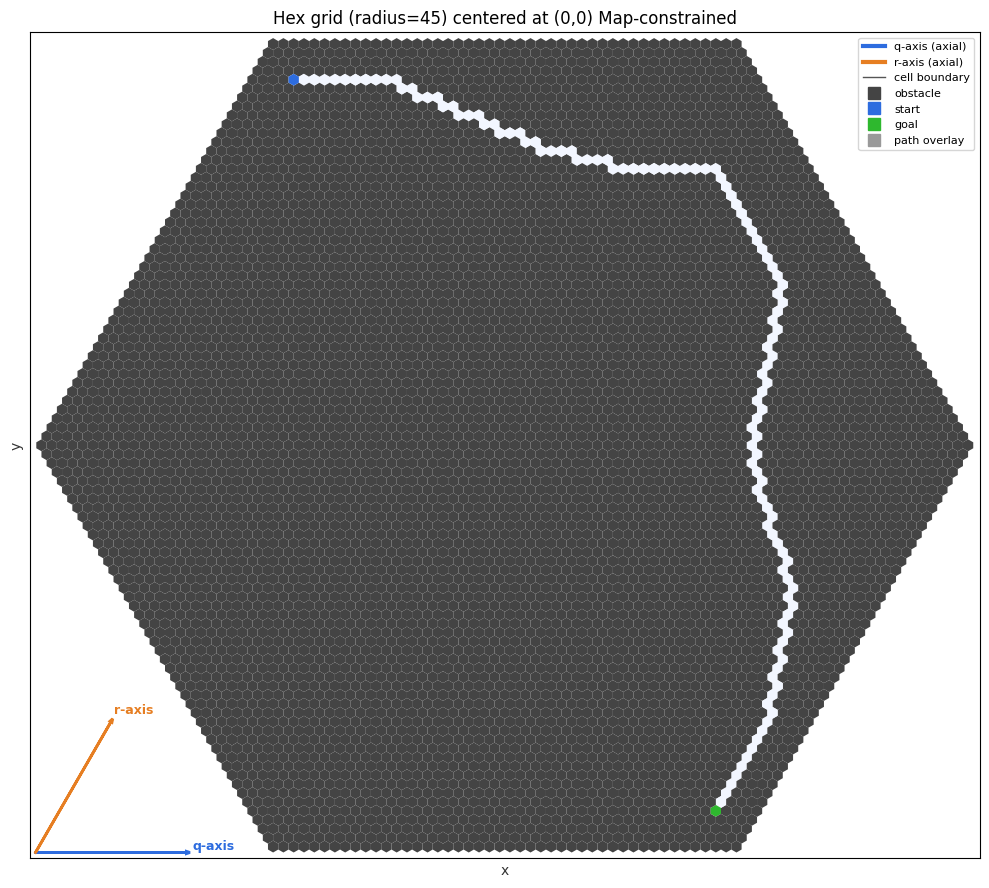

In [32]:
obs_density = 0.05
hex_size = 1
n_obs = int(obs_density * 3 * RADIUS * (RADIUS + 1))
start = HexCoord(q=-RADIUS + 4, r=RADIUS - 4)
#start = HexCoord(0,0)
goal = HexCoord(q=RADIUS - 4, r=-RADIUS + 4)

obs = set(build_obstacle_map(
    center = HexCoord(0,0),
    radius = RADIUS,
    types = [("fill_all", {})],
    exclude=[start, goal],
    seed=42
).keys())

obs = obs - {start, goal}
obs = obs - problem.generate_collision_radius_map(problem.collision_radius, set(fsolution_path))
obs = obs - set(fsolution_path)

hg = HexGrid(hex_size, obs)

problem = HStarProblem(
    hg, # hex grid
    start,
    goal,
    a_max,  # maximum acceleration (for acceleration phase)
    a_min,  # maximum deceleration (positive value; used with sign as needed)
    collision_radius = collision_radius,
    jps_horizon =  jps_horizon,
    ay_window_ms = ay_window_ms,
    n_step = n_step,   
    start_v = VelocityState(0, None),
    goal_v = VelocityState(0, None)
)
#problem.goal_v=VelocityState(0, problem.DIRECTIONS.index(HexCoord(-1,2))) # approach from the northeast
hs = HStarSearch(
    problem = problem,
    heuristic = h_cost_travel_time
)

plot_hex_grid_2(
    hg.obstacles.union(problem.collision_radius_map),
    start,
    HexCoord(0,0),
    RADIUS,
    goal = goal,
    figsize=(10,10),
    show_coords = False,
    #path = hexes_in_between_solid(HexCoord(q=0, r=0), HexCoord(q=14, r=10)),
    #path=problem.get_available_hexes_in_dir(start, problem.DIRECTIONS[0], ray_range = 50),
    #path=problem.actions(hs.root),
    #path=set(unique_direction_vectors_up_to_n(HexCoord(0,0), RADIUS)),
    facecolor_path = "#999999",
    #path = set([n.location for n in fsolution[-24:-21]]),
    #path = fsolution,
    linewidth=0,
    plt_title = f"Map-constrained",
    save_path=f"map-constrained",
)

# Draw the outer boundary


In [33]:
import time
start_t = time.time()
fsolution = hs.search()
fsolution_path = construct_full_solution(fsolution)
search_time = time.time() - start_t
print(f'Search time: {search_time:.2f}s')
print(f'Solution cost   : {fsolution[-1].f_cost}')


Search time: 0.02s
Solution cost   : 15.425749680837647


<Axes: title={'center': 'Hex grid (radius=45) centered at (0,0) Solution Forward Constrained'}, xlabel='x', ylabel='y'>

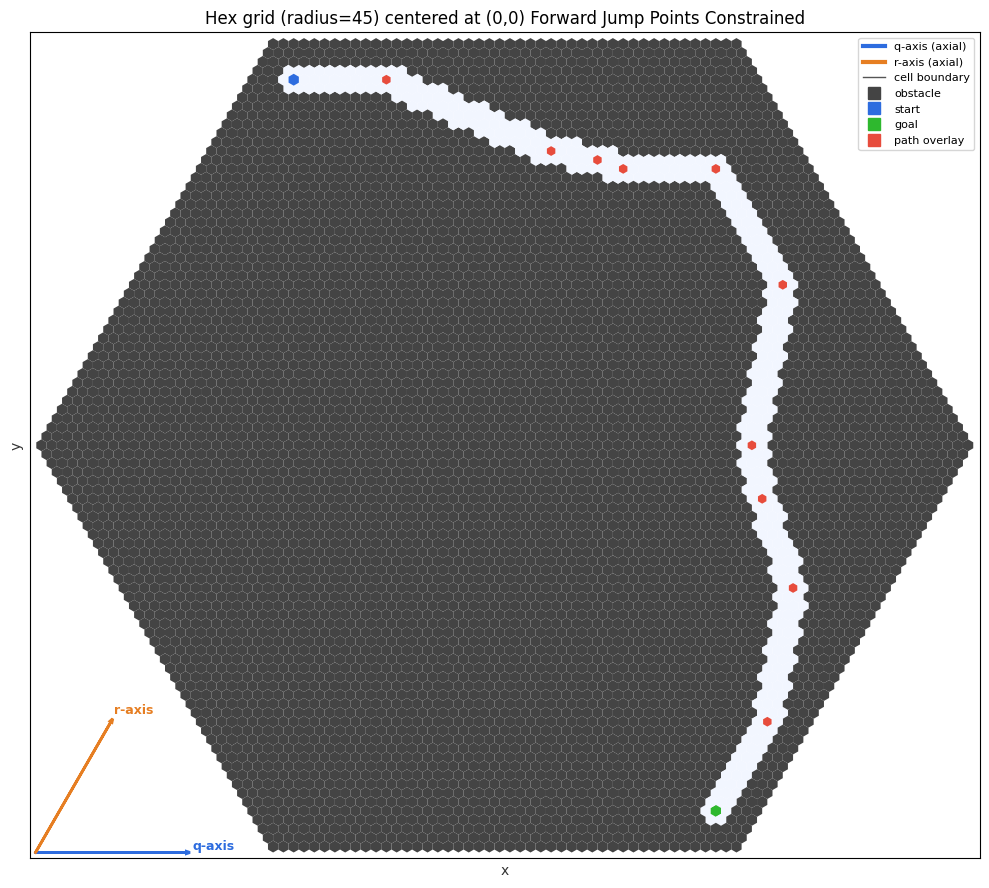

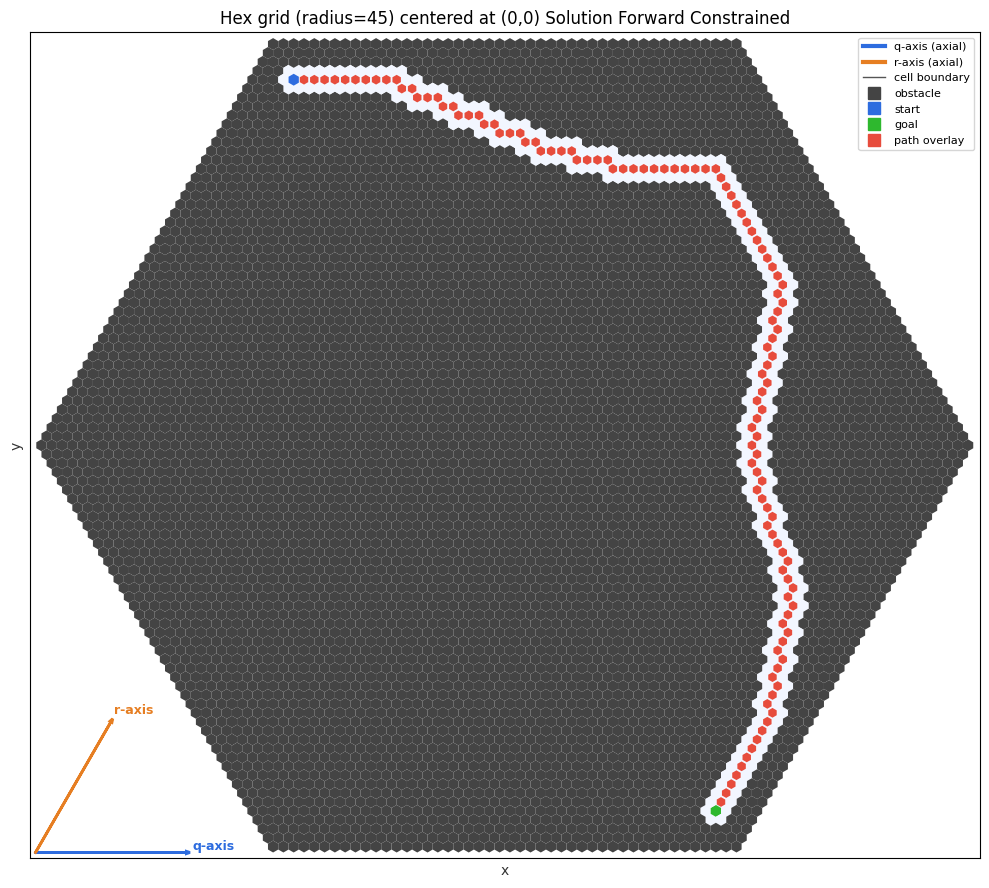

In [34]:
plot_hex_grid_2(
    obs,
    start,
    HexCoord(0,0),
    RADIUS,
    goal = goal,
    figsize=(10,10),
    show_coords = False,
    path = set([n.location for n in fsolution]),
    linewidth=0,
    plt_title = f"Forward Jump Points Constrained",
    save_path=f"jump-points-forward-c",
)
plot_hex_grid_2(
    obs,
    start,
    HexCoord(0,0),
    RADIUS,
    goal = goal,
    figsize=(10,10),
    show_coords = False,
    path = fsolution_path,
    linewidth=0,
    plt_title = f"Solution Forward Constrained",
    save_path=f"solution-forward-c",
)

In [35]:
problem_r = problem.reverse()
problem_r.start_v
hs_r = HStarSearch(
    problem = problem_r,
    heuristic = h_cost_travel_time
)
import time
start_t = time.time()
rsolution = hs_r.search()
rsolution_path = construct_full_solution(rsolution)
search_time = time.time() - start_t
print(f'Search time: {search_time:.2f}s')
print(f'Solution cost   : {rsolution[-1].f_cost}')
print(f'F Solution cost : {fsolution[-1].f_cost}')

Search time: 0.03s
Solution cost   : 15.425749680837647
F Solution cost : 15.425749680837647


<Axes: title={'center': 'Hex grid (radius=45) centered at (0,0) Solution Reverse'}, xlabel='x', ylabel='y'>

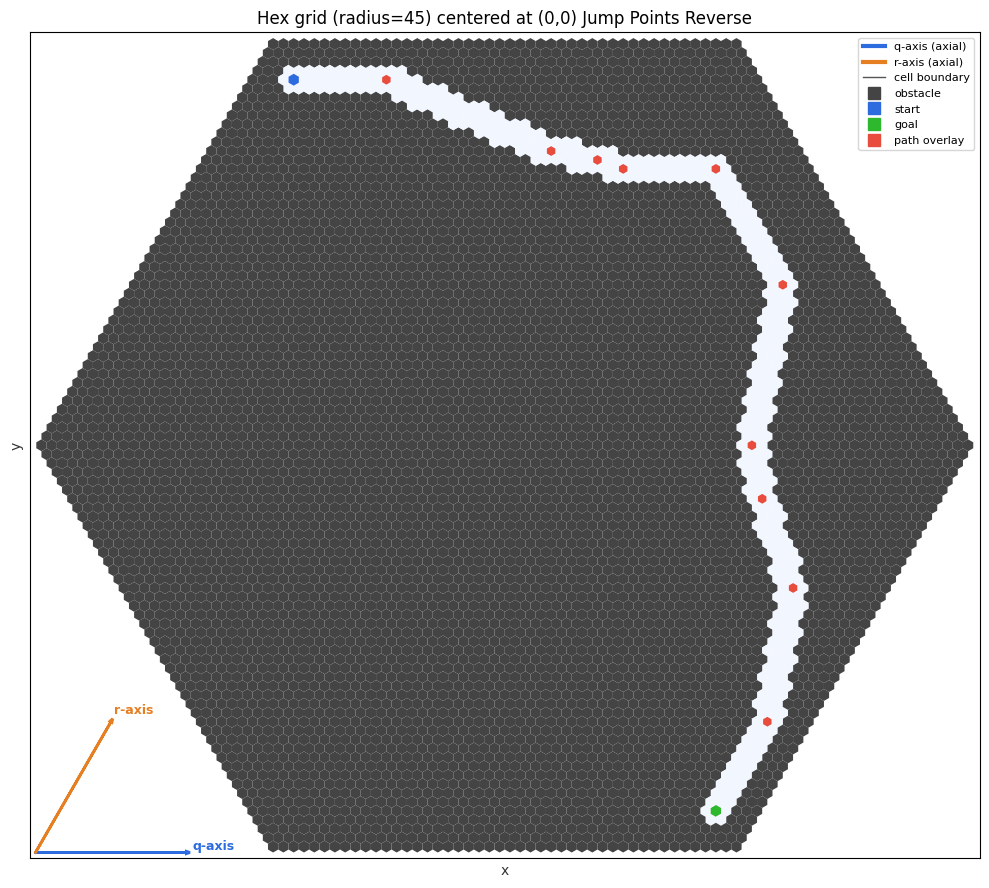

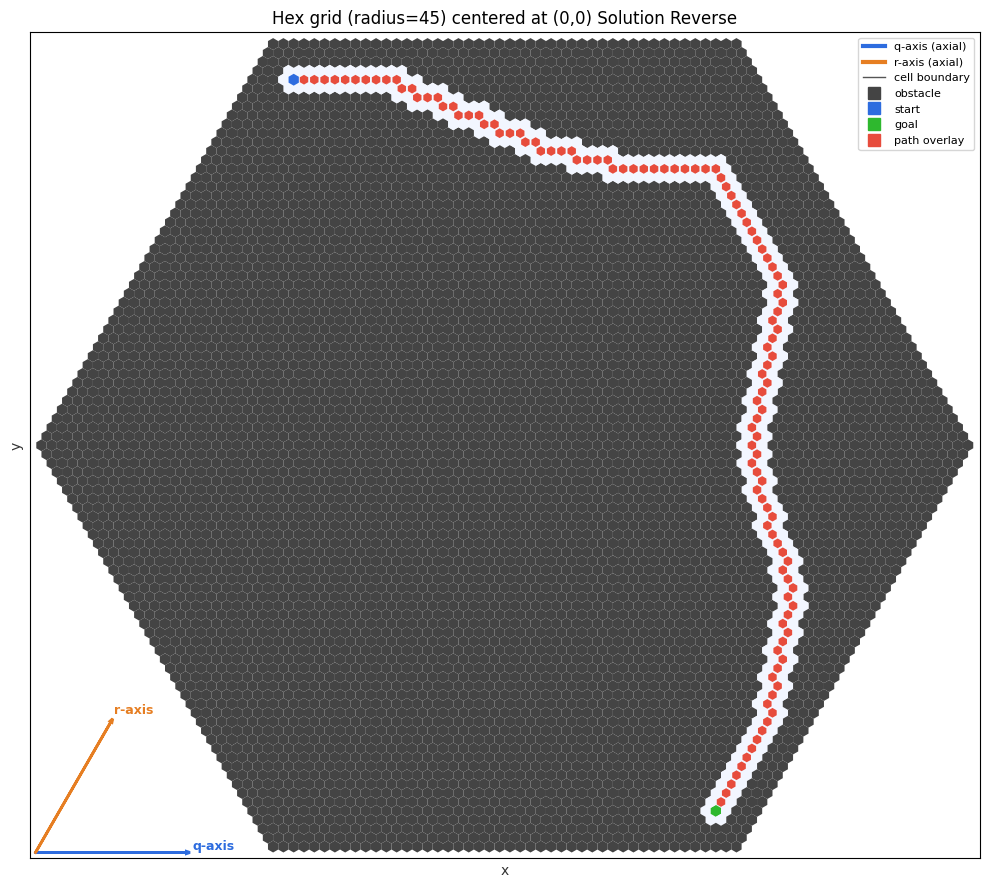

In [36]:
plot_hex_grid_2(
    obs,
    start,
    HexCoord(0,0),
    RADIUS,
    goal = goal,
    figsize=(10,10),
    show_coords = False,
    path = set([n.location for n in rsolution]),
    linewidth=0,
    plt_title = f"Jump Points Reverse",
    save_path=f"jump-points-reverse",
)
plot_hex_grid_2(
    obs,
    start,
    HexCoord(0,0),
    RADIUS,
    goal = goal,
    figsize=(10,10),
    show_coords = False,
    path = rsolution_path,
    linewidth=0,
    plt_title = f"Solution Reverse",
    save_path=f"solution-reverse-c",
)

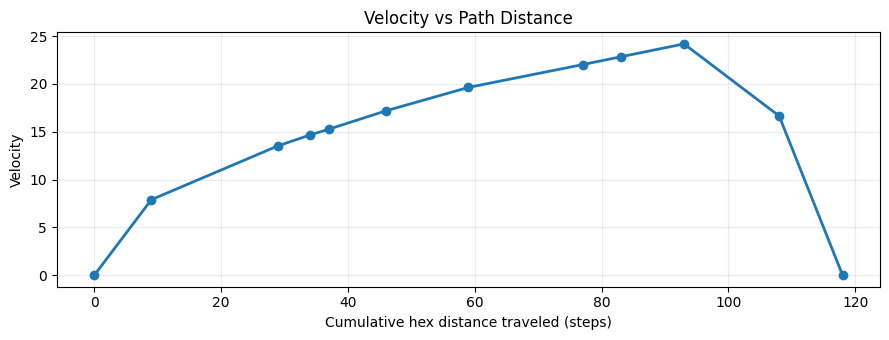

<Axes: title={'center': 'Velocity vs Path Distance'}, xlabel='Cumulative hex distance traveled (steps)', ylabel='Velocity'>

In [37]:
plot_velocity_profile(fsolution)

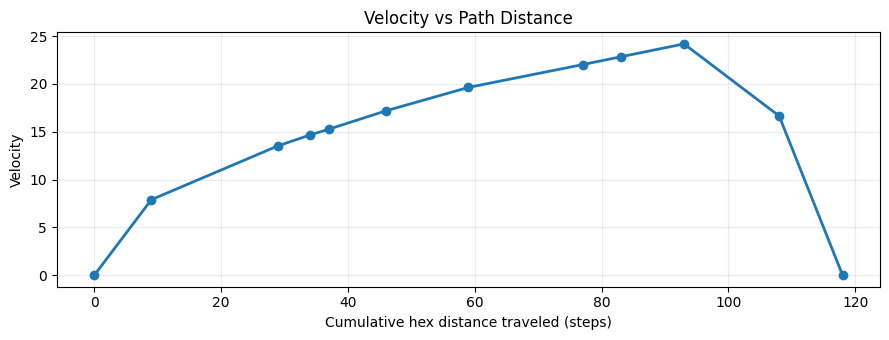

<Axes: title={'center': 'Velocity vs Path Distance'}, xlabel='Cumulative hex distance traveled (steps)', ylabel='Velocity'>

In [38]:
plot_velocity_profile(list(reversed(rsolution)))

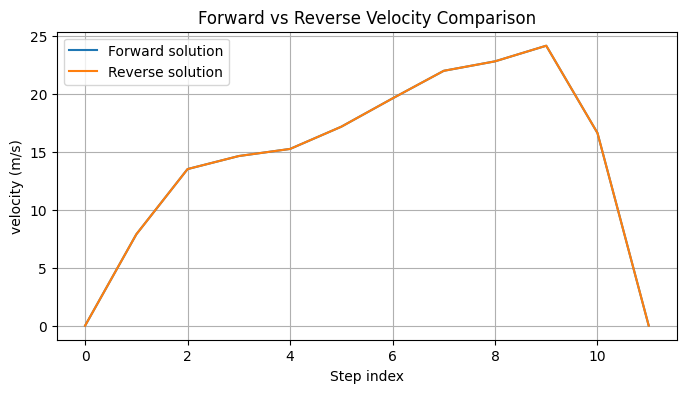

In [52]:

f_vals = [f.velocity.magnitude for f in fsolution]
r_vals = list(reversed([f.velocity.magnitude for f in rsolution]))

plt.figure(figsize=(8, 4))

plt.plot(f_vals, label="Forward solution")
plt.plot(r_vals, label="Reverse solution")

plt.xlabel("Step index")
plt.ylabel("velocity (m/s)")
plt.title("Forward vs Reverse Velocity Comparison")

plt.legend()
plt.grid(True)

plt.show()


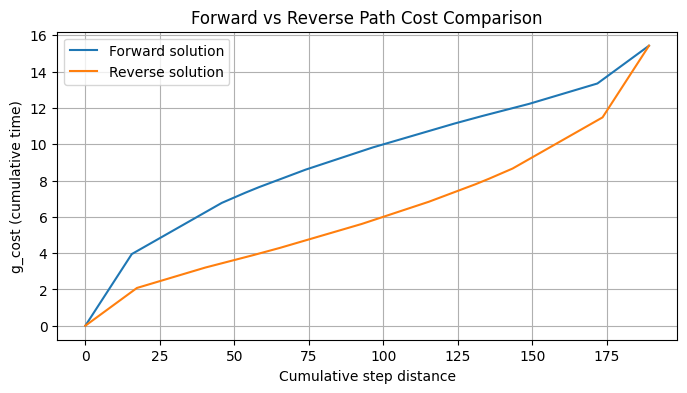

In [40]:
f_x = list(itertools.accumulate(
    (f.step_distance or 0.0) for f in fsolution
))
r_x = list(itertools.accumulate(
    (f.step_distance or 0.0) for f in rsolution
))

f_vals = [f.g_cost for f in fsolution]
r_vals = [f.g_cost for f in rsolution]

plt.figure(figsize=(8, 4))

plt.plot(f_x, f_vals, label="Forward solution")
plt.plot(r_x, r_vals, label="Reverse solution")

plt.xlabel("Cumulative step distance")
plt.ylabel("g_cost (cumulative time)")
plt.title("Forward vs Reverse Path Cost Comparison")

plt.legend()
plt.grid(True)

plt.show()

In [68]:
from queue import PriorityQueue
from itertools import count
from typing import Optional, Dict, Tuple, List, Callable
from hexgrid import Node
from hexgeometry import reverse_dir, euclid_center_distance
from hexstar import travel_time_symmetric
import time
import math
HeuristicFn = Callable[["HStarProblem", "Node"], float]

class BidHStarSearch(HStarSearch):
    """
    Bidirectional H* search using one forward problem and one reversed problem.

    Notes
    -----
    - Uses location-only state matching by default to stay consistent with the
      current HStarSearch.closed_set behavior.
    - If you need stronger correctness for velocity/heading-constrained joins,
      override state_key().
    """

    def __init__(
        self,
        problem: HStarProblem,
        heuristic: Optional[HeuristicFn] = h_cost_travel_time,
        join_velocity_tolderance: Optional[int] = None,
    ) -> None:
        self.problem = problem
        self.reverse_problem = problem.reverse()
        self.h: HeuristicFn = heuristic
        self.join_velocity_tolderance = 0 if join_velocity_tolderance is None else join_velocity_tolderance
        
        # Forward frontier / reached
        self.frontier_f = PriorityQueue()
        self.reached_f: Dict[HexCoord, Node] = {}

        # Backward frontier / reached
        self.frontier_b = PriorityQueue()
        self.reached_b: Dict[HexCoord, Node] = {}

        # Separate counters so tie-breaking is stable within each frontier
        self._counter_f = count()
        self._counter_b = count()

        self.best_solution_cost = math.inf
        self.best_meeting_pair: Optional[Tuple[Node, Node]] = None

        self.benchmarks = {
            "states_reached": 0,
            "nodes_expanded": 0,
            "search_time": 0,
            "solution_cost": math.inf,
            "solution_length": 0,
            "open_set_sizes_f": [],
            "open_set_sizes_b": [],
            "reached_sizes_f": [],
            "reached_sizes_b": [],
        }

        self.initialize_bidirectional()

    # ------------------------------------------------------------------
    # Initialization
    # ------------------------------------------------------------------

    def initialize_bidirectional(self) -> None:
        # Forward root
        self.root_f = Node(
            location=self.problem.start,
            velocity=self.problem.start_v,
            parent=None,
            g_cost=0.0,
            h_cost=0.0,
            f_cost=0.0,
        )
        self.root_f.h_cost = self.h(self.problem, self.root_f)
        self.root_f.f_cost = self.root_f.g_cost + self.root_f.h_cost

        # Backward root
        self.root_b = Node(
            location=self.reverse_problem.start,
            velocity=self.reverse_problem.start_v,
            parent=None,
            g_cost=0.0,
            h_cost=0.0,
            f_cost=0.0,
        )
        self.root_b.h_cost = self.h(self.reverse_problem, self.root_b)
        self.root_b.f_cost = self.root_b.g_cost + self.root_b.h_cost

        self.frontier_f.put((self.root_f.f_cost, -next(self._counter_f), self.root_f))
        self.frontier_b.put((self.root_b.f_cost, -next(self._counter_b), self.root_b))

        self.reached_f[self.state_key(self.root_f)] = self.root_f
        self.reached_b[self.state_key(self.root_b)] = self.root_b

    # ------------------------------------------------------------------
    # State matching
    # ------------------------------------------------------------------

    def state_key(self, node: Node):
        """
        Default matching key for reached tables and forward/backward joining.

        Minimal-change version uses location only, matching your existing
        HStarSearch behavior.
        """
        return node.location

    # ------------------------------------------------------------------
    # Frontier helpers
    # ------------------------------------------------------------------

    def _peek_priority(self, frontier: PriorityQueue) -> float:
        if frontier.empty():
            return math.inf
        item = frontier.queue[0]
        return item[0]

    def _push_forward(self, node: Node) -> None:
        f = node.g_cost + self.h(self.problem, node)
        self.frontier_f.put((f, -next(self._counter_f), node))

    def _push_backward(self, node: Node) -> None:
        f = node.g_cost + self.h(self.reverse_problem, node)
        self.frontier_b.put((f, -next(self._counter_b), node))

    # ------------------------------------------------------------------
    # Termination
    # ------------------------------------------------------------------

    def terminated(self) -> bool:
        """
        Stop when:
          - either frontier is empty, or
          - current best upper bound is no worse than the sum of the best
            lower bounds from both frontiers.

        This is the natural analogue of the textbook bidirectional A* stopping rule.
        """
        if self.frontier_f.empty() or self.frontier_b.empty():
            return True

        lower_bound = self._peek_priority(self.frontier_f) + self._peek_priority(self.frontier_b)
        return self.best_solution_cost <= lower_bound + self.problem.epsilon

    # ------------------------------------------------------------------
    # Main search
    # ------------------------------------------------------------------

    def search(self) -> Optional[List[Node]]:
        start_time = time.time()

        while not self.terminated():
            self.benchmarks["open_set_sizes_f"].append(self.frontier_f.qsize())
            self.benchmarks["open_set_sizes_b"].append(self.frontier_b.qsize())
            self.benchmarks["reached_sizes_f"].append(len(self.reached_f))
            self.benchmarks["reached_sizes_b"].append(len(self.reached_b))

            top_f = self._peek_priority(self.frontier_f)
            top_b = self._peek_priority(self.frontier_b)

            if top_f <= top_b:
                self._proceed_forward()
            else:
                self._proceed_backward()

        self.benchmarks["search_time"] = time.time() - start_time

        if self.best_meeting_pair is None:
            return None

        f_meet, b_meet = self.best_meeting_pair
        path = self.stitch_solution(f_meet, b_meet)

        self.benchmarks["solution_cost"] = self.best_solution_cost
        self.benchmarks["solution_length"] = len(path)
        return path

    # ------------------------------------------------------------------
    # One expansion step in each direction
    # ------------------------------------------------------------------

    def _proceed_forward(self) -> None:
        if self.frontier_f.empty():
            return

        _, _, node = self.frontier_f.get(False)
        self.benchmarks["nodes_expanded"] += 1

        # Expand using the forward problem
        for child in self._expand_with_problem(self.problem, node):
            self.benchmarks["states_reached"] += 1
            s = self.state_key(child)

            prev_best = self.reached_f.get(s)
            if prev_best is None or child.g_cost < prev_best.g_cost - self.problem.epsilon:
                self.reached_f[s] = child
                self._push_forward(child)

            # Check meet against backward reached table
            mate = self.reached_b.get(s)
            if mate is not None:
                candidate_cost = child.g_cost + mate.g_cost
                if candidate_cost < self.best_solution_cost - self.problem.epsilon:
                    self.best_solution_cost = candidate_cost
                    self.best_meeting_pair = (child, mate)

    def _proceed_backward(self) -> None:
        if self.frontier_b.empty():
            return

        _, _, node = self.frontier_b.get(False)
        self.benchmarks["nodes_expanded"] += 1

        # Expand using the reverse problem
        for child in self._expand_with_problem(self.reverse_problem, node):
            self.benchmarks["states_reached"] += 1
            s = self.state_key(child)

            prev_best = self.reached_b.get(s)
            if prev_best is None or child.g_cost < prev_best.g_cost - self.reverse_problem.epsilon:
                self.reached_b[s] = child
                self._push_backward(child)

            # Check meet against forward reached table
            mate = self.reached_f.get(s)
            if mate is not None:
                candidate_cost = child.g_cost + mate.g_cost
                if candidate_cost < self.best_solution_cost - self.problem.epsilon:
                    self.best_solution_cost = candidate_cost
                    # store as (forward, backward)
                    self.best_meeting_pair = (mate, child)

    # ------------------------------------------------------------------
    # Expansion using an arbitrary problem instance
    # ------------------------------------------------------------------

    def _expand_with_problem(self, problem: HStarProblem, node: Node) -> List[Node]:
        children: List[Node] = []
        for action in problem.actions(node):
            child = problem.result(node, action)

            # Optional consistency check, same style as HStarSearch.expand()
            if problem.heuristic_consistent_flag:
                problem.heuristic_consistent_flag = self.check_h_consistency(problem, child, self.h)

            children.append(child)
        return children

    # ------------------------------------------------------------------
    # Path utilities
    # ------------------------------------------------------------------

    def reconstruct_path(self, node: Node) -> List[Node]:
        out: List[Node] = []
        cur = node
        while cur is not None:
            out.append(cur)
            cur = cur.parent
        out.reverse()
        return out


    def stitch_solution(self, meet_f: Node, meet_b: Node) -> List[Node]:
        """
        Build a single forward-facing node chain from:
          start -> ... -> meet_f == meet_b <- ... <- goal  (reverse tree)

        The backward half is copied into new nodes so the final returned list
        behaves like a normal forward path.

        Notes
        -----
        - This copies the reverse-side nodes.
        - Directions on the copied suffix are flipped with reverse_dir().
        - g_cost is recomputed incrementally on the copied suffix.
        """
        forward_path = self.reconstruct_path(meet_f)
        backward_path = self.reconstruct_path(meet_b)  # [goal, ..., meet]

        # We want the suffix from meet -> ... -> goal
        # backward_path is [goal, ..., meet], so reverse it and skip duplicated meet
        suffix_rev = list(reversed(backward_path))  # [meet, ..., goal]
        suffix_rev = suffix_rev[1:]  # skip duplicate meet

        if not suffix_rev:
            return forward_path

        stitched = list(forward_path)
        parent = stitched[-1]

        for rev_node in suffix_rev:
            # The reverse search direction index is opposite in the stitched forward path
            new_dir = None
            if rev_node.velocity is not None and rev_node.velocity.direction is not None:
                new_dir = problem.reverse_dir_idx(rev_node.velocity.direction)

            copied = Node(
                location=rev_node.location,
                velocity=VelocityState(
                    magnitude=rev_node.velocity.magnitude if rev_node.velocity is not None else None,
                    direction=new_dir,
                ),
                parent=parent,
                step_distance=rev_node.step_distance,
                g_cost=0.0,
                h_cost=0.0,
                f_cost=0.0,
            )

            # Recompute cumulative cost on the copied suffix
            s = copied.step_distance
            if s is None:
                # fallback if step_distance wasn't stored
                s = euclid_center_distance(parent.location, copied.location)

            v1 = 0.0 if parent.velocity is None or parent.velocity.magnitude is None else parent.velocity.magnitude
            v2 = 0.0 if copied.velocity is None or copied.velocity.magnitude is None else copied.velocity.magnitude
            dt = travel_time_symmetric(v1, v2, s)

            copied.g_cost = parent.g_cost + dt
            copied.h_cost = self.h(self.problem, copied)
            copied.f_cost = copied.g_cost + copied.h_cost

            stitched.append(copied)
            parent = copied

        return stitched


In [71]:
bi_s = BidHStarSearch(problem)
bi_solution = bi_s.search()
bi_solution_path = construct_full_solution(rsolution)
benchmarks_bi = bi_s.get_benchmarks()
print(f'Search time: {benchmarks_bi["search_time"]}s')
print(f'Solution cost r: {benchmarks_bi["solution_cost"]}')
print(f'Solution cost f: {benchmarks_bi["solution_cost"]}')

Search time: 0.02458930015563965s
Solution cost r: 10.091345791762684
Solution cost f: 10.091345791762684


<Axes: title={'center': 'Hex grid (radius=45) centered at (0,0) Solution Reverse'}, xlabel='x', ylabel='y'>

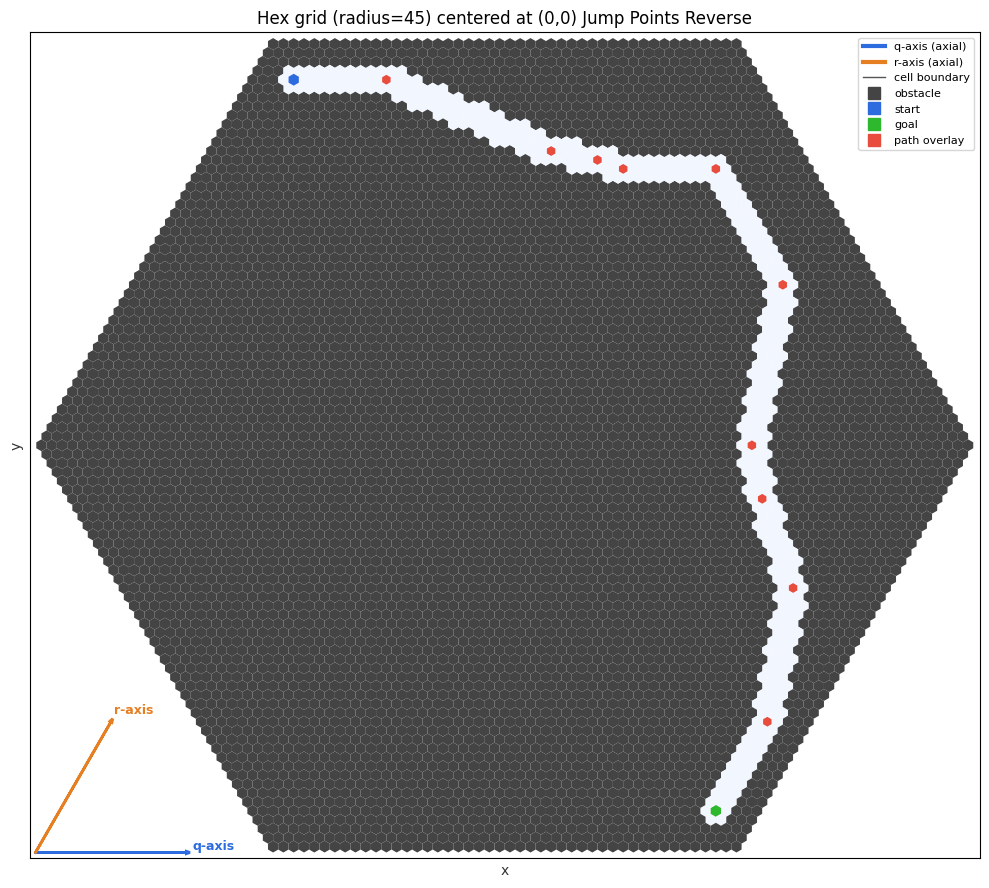

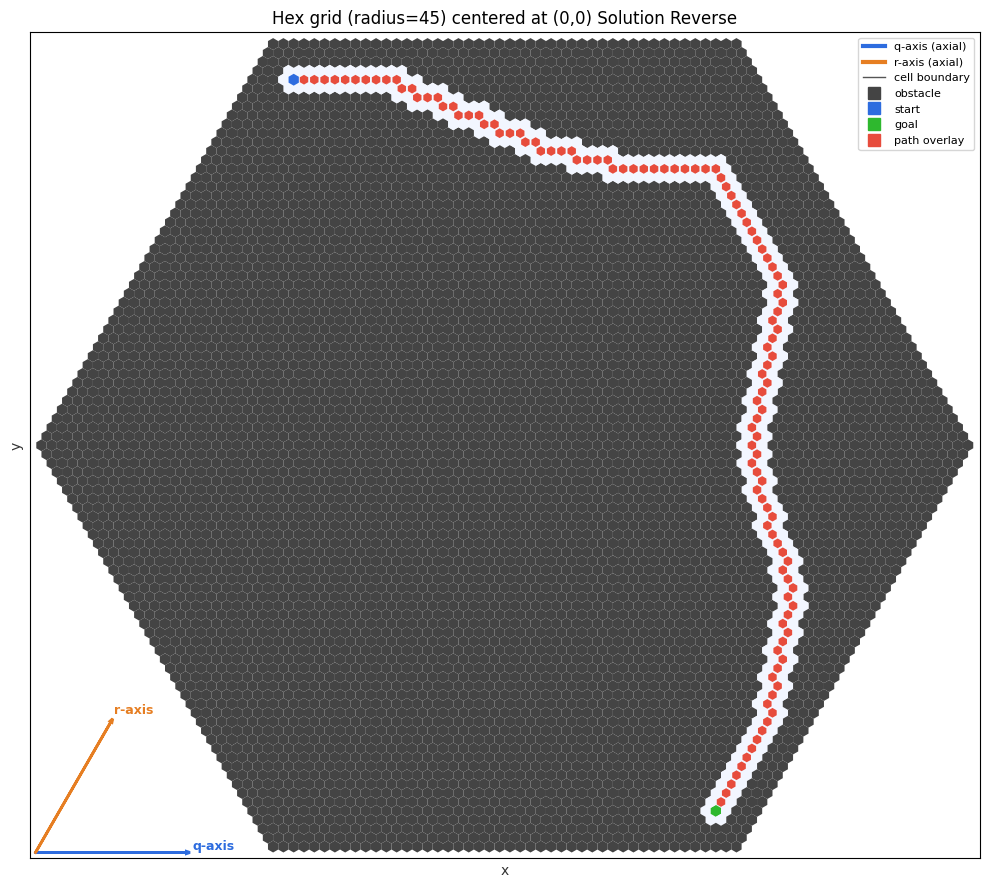

In [72]:
plot_hex_grid_2(
    obs,
    start,
    HexCoord(0,0),
    RADIUS,
    goal = goal,
    figsize=(10,10),
    show_coords = False,
    path = set([n.location for n in bi_solution]),
    linewidth=0,
    plt_title = f"Jump Points Reverse",
    save_path=f"jump-points-reverse",
)
plot_hex_grid_2(
    obs,
    start,
    HexCoord(0,0),
    RADIUS,
    goal = goal,
    figsize=(10,10),
    show_coords = False,
    path = bi_solution_path,
    linewidth=0,
    plt_title = f"Solution Reverse",
    save_path=f"solution-reverse-c",
)